In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [15]:
final=pd.read_csv("/content/input_yield_sar.csv")

In [16]:
final

,Year,Precipitation,maxtemp,mintemp,avgtemp,specifichumidity,relativehumidity,surfacepressure,dewpoints,minwindspeed,maxwindspeed,cloudcoverage,Nitrogen,Phosphorus,Pottasium,pH,VH_mean,VV_mean,RVI,Yield
0,2015,496.85,33.33,19.83,13.50,0.011725,51.94,94.15,14.38,2.37,5.85,0.55,-1,1,2,2,-16.966225,-10.233417,0.649242,96.64
1,2016,801.98,32.84,19.31,13.53,0.011382,53.13,94.10,13.68,2.48,5.91,0.54,0,2,2,2,-16.965433,-10.101258,0.663100,124.38
2,2017,827.51,32.74,19.21,13.53,0.011535,53.82,94.08,13.67,2.33,5.78,0.55,-1,1,1,2,-18.405242,-10.914717,0.672425,99.00
3,2018,353.50,33.03,19.62,13.41,0.011057,50.04,94.09,13.36,2.29,5.93,0.56,-2,-1,0,3,-18.574225,-10.863525,0.652692,67.29
4,2019,1057.54,32.80,19.20,13.60,0.011498,53.60,94.10,13.60,2.30,5.80,0.60,-1,1,2,2,-18.144833,-10.435917,0.631733,99.00
5,2020,745.34,32.76,19.30,13.53,0.011365,50.55,94.09,13.48,2.46,5.95,0.56,-1,1,2,2,-17.909733,-10.163892,0.638483,95.50
6,2021,780.50,32.50,19.10,13.45,0.011400,51.20,94.07,13.55,2.50,5.90,0.55,0,1,1,2,-17.776767,-10.090050,0.646925,100.20
7,2022,810.30,32.30,18.90,13.35,0.011500,52.00,94.05,13.65,2.55,5.85,0.54,0,2,2,2,-17.204350,-9.702508,0.666175,103.80
8,2023,840.80,32.10,18.70,13.25,0.011600,53.00,94.03,13.75,2.60,5.80,0.53,-1,1,2,2,-17.936492,-10.155967,0.648992,106.50
9,2024,870.50,31.90,18.50,13.15,0.011700,54.00,94.01,13.85,2.65,5.75,0.52,0,2,2,2,-17.531683,-9.997567,0.657925,109.20


In [17]:
final.shape

(11, 20)

In [18]:
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              11 non-null     int64  
 1   Precipitation     11 non-null     float64
 2   maxtemp           11 non-null     float64
 3   mintemp           11 non-null     float64
 4   avgtemp           11 non-null     float64
 5   specifichumidity  11 non-null     float64
 6   relativehumidity  11 non-null     float64
 7   surfacepressure   11 non-null     float64
 8   dewpoints         11 non-null     float64
 9   minwindspeed      11 non-null     float64
 10  maxwindspeed      11 non-null     float64
 11  cloudcoverage     11 non-null     float64
 12  Nitrogen          11 non-null     int64  
 13  Phosphorus        11 non-null     int64  
 14  Pottasium         11 non-null     int64  
 15  pH                11 non-null     int64  
 16  VH_mean           11 non-null     float64
 17 

In [19]:
#Creating correlation for precipitation
#Creating the correlation matrix for the features
corr_matrix=final.corr()
corr_matrix

,Year,Precipitation,maxtemp,mintemp,avgtemp,specifichumidity,relativehumidity,surfacepressure,dewpoints,minwindspeed,maxwindspeed,cloudcoverage,Nitrogen,Phosphorus,Pottasium,pH,VH_mean,VV_mean,RVI,Yield
Year,1.000000,0.465316,-0.944301,-0.916764,-0.831574,0.382450,0.346118,-0.932276,-0.077284,0.822394,-0.526500,-0.545222,0.233126,0.217643,0.043853,-0.200000,-0.114671,0.483142,-0.116521,0.242521
Precipitation,0.465316,1.000000,-0.568884,-0.656821,-0.141764,0.474482,0.707827,-0.459602,-0.043050,0.391797,-0.553340,-0.007319,0.479301,0.628703,0.485601,-0.721023,0.026592,0.333590,-0.126412,0.674065
maxtemp,-0.944301,-0.568884,1.000000,0.992020,0.862624,-0.502156,-0.575244,0.980966,-0.019862,-0.887113,0.663508,0.686988,-0.349910,-0.378347,-0.079686,0.322843,0.021679,-0.462062,-0.110315,-0.467571
mintemp,-0.916764,-0.656821,0.992020,1.000000,0.818849,-0.539424,-0.656084,0.963145,-0.031344,-0.859093,0.711313,0.637748,-0.361918,-0.424019,-0.129593,0.384174,0.024358,-0.440340,-0.094874,-0.524529
avgtemp,-0.831574,-0.141764,0.862624,0.818849,1.000000,-0.505329,-0.444421,0.885499,-0.262827,-0.843561,0.634803,0.829908,-0.101698,-0.126097,0.104618,0.027265,-0.043322,-0.358649,-0.151311,-0.241898
specifichumidity,0.382450,0.474482,-0.502156,-0.539424,-0.505329,1.000000,0.751741,-0.385983,0.809894,0.570886,-0.803638,-0.496399,0.304361,0.558398,0.476426,-0.717639,0.405358,0.398078,0.042533,0.599309
relativehumidity,0.346118,0.707827,-0.575244,-0.656084,-0.444421,0.751741,1.000000,-0.514482,0.424543,0.445389,-0.895004,-0.385777,0.256451,0.501568,0.257793,-0.540131,0.107472,0.095189,0.210474,0.679062
surfacepressure,-0.932276,-0.459602,0.980966,0.963145,0.885499,-0.385983,-0.514482,1.000000,0.075747,-0.830035,0.631397,0.692603,-0.226521,-0.233386,0.080614,0.151002,0.152298,-0.330756,-0.162364,-0.334968
dewpoints,-0.077284,-0.043050,-0.019862,-0.031344,-0.262827,0.809894,0.424543,0.075747,1.000000,0.252797,-0.474732,-0.378813,0.118912,0.325994,0.378131,-0.437208,0.592761,0.257844,0.067407,0.357300
minwindspeed,0.822394,0.391797,-0.887113,-0.859093,-0.843561,0.570886,0.445389,-0.830035,0.252797,1.000000,-0.473066,-0.840422,0.506622,0.530937,0.274687,-0.434633,0.365188,0.713671,0.125250,0.620774


In [20]:
mask = np.zeros_like(corr_matrix, dtype=np.bool)
mask[np.triu_indices_from(mask)]= True

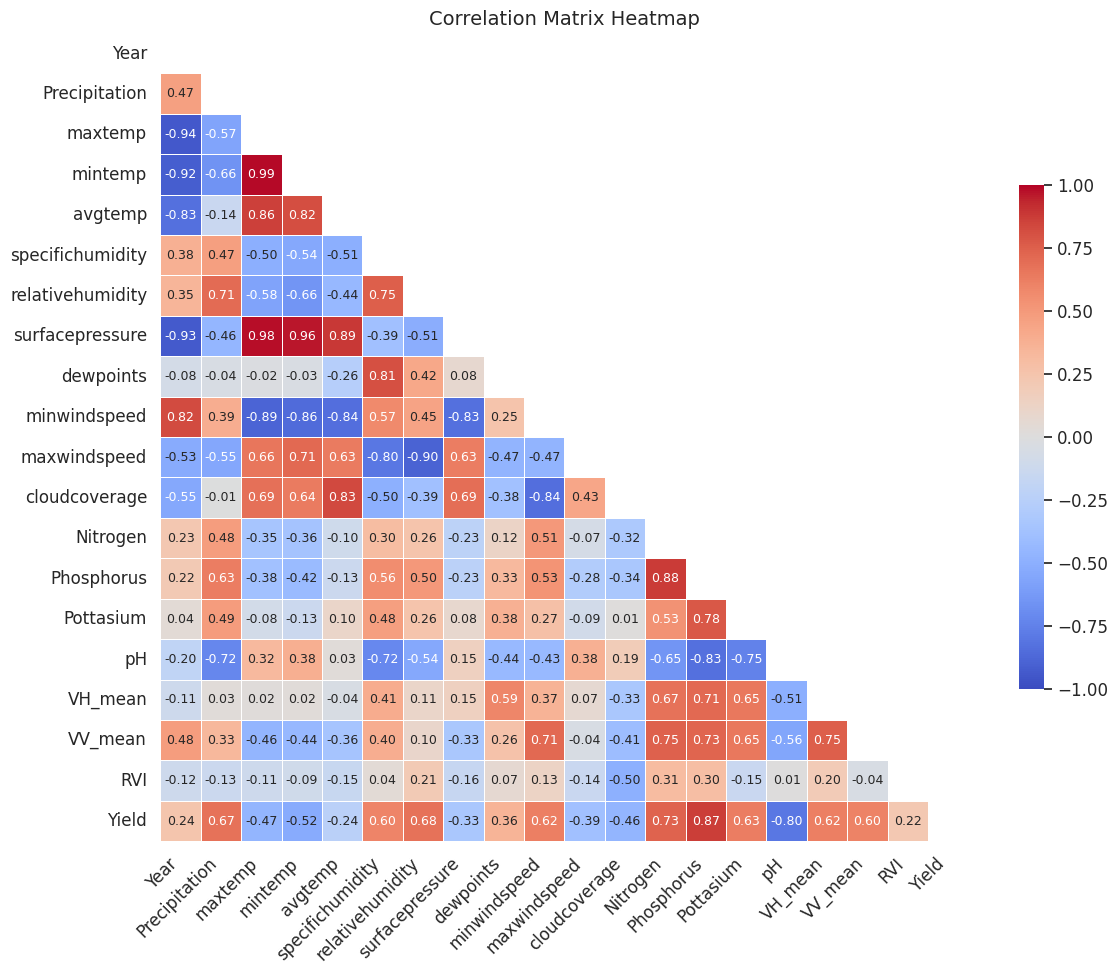

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.set_style("white")
sns.set_context("notebook", font_scale=1.1)

plt.figure(figsize=(12, 10))

ax = sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize": 9},
    cbar_kws={"shrink": 0.6}
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.title("Correlation Matrix Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
final = final.drop(
    ['maxtemp', 'mintemp', 'avgtemp', 'pH', 'cloudcoverage', 'maxwindspeed', 'minwindspeed'],
    axis=1
)

In [25]:
final.shape

(11, 13)

In [26]:
final1=final.iloc[:,:].values

In [27]:
final1

array([[ 2.01500000e+03,  4.96850000e+02,  1.17250000e-02,
         5.19400000e+01,  9.41500000e+01,  1.43800000e+01,
        -1.00000000e+00,  1.00000000e+00,  2.00000000e+00,
        -1.69662250e+01, -1.02334167e+01,  6.49241667e-01,
         9.66400000e+01],
       [ 2.01600000e+03,  8.01980000e+02,  1.13820000e-02,
         5.31300000e+01,  9.41000000e+01,  1.36800000e+01,
         0.00000000e+00,  2.00000000e+00,  2.00000000e+00,
        -1.69654333e+01, -1.01012583e+01,  6.63100000e-01,
         1.24380000e+02],
       [ 2.01700000e+03,  8.27510000e+02,  1.15350000e-02,
         5.38200000e+01,  9.40800000e+01,  1.36700000e+01,
        -1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
        -1.84052417e+01, -1.09147167e+01,  6.72425000e-01,
         9.90000000e+01],
       [ 2.01800000e+03,  3.53500000e+02,  1.10570000e-02,
         5.00400000e+01,  9.40900000e+01,  1.33600000e+01,
        -2.00000000e+00, -1.00000000e+00,  0.00000000e+00,
        -1.85742250e+01, -1.08635250e

In [28]:
X=final1[:,:-1]
y=final1[:,-1]

In [29]:
X

array([[ 2.01500000e+03,  4.96850000e+02,  1.17250000e-02,
         5.19400000e+01,  9.41500000e+01,  1.43800000e+01,
        -1.00000000e+00,  1.00000000e+00,  2.00000000e+00,
        -1.69662250e+01, -1.02334167e+01,  6.49241667e-01],
       [ 2.01600000e+03,  8.01980000e+02,  1.13820000e-02,
         5.31300000e+01,  9.41000000e+01,  1.36800000e+01,
         0.00000000e+00,  2.00000000e+00,  2.00000000e+00,
        -1.69654333e+01, -1.01012583e+01,  6.63100000e-01],
       [ 2.01700000e+03,  8.27510000e+02,  1.15350000e-02,
         5.38200000e+01,  9.40800000e+01,  1.36700000e+01,
        -1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
        -1.84052417e+01, -1.09147167e+01,  6.72425000e-01],
       [ 2.01800000e+03,  3.53500000e+02,  1.10570000e-02,
         5.00400000e+01,  9.40900000e+01,  1.33600000e+01,
        -2.00000000e+00, -1.00000000e+00,  0.00000000e+00,
        -1.85742250e+01, -1.08635250e+01,  6.52691667e-01],
       [ 2.01900000e+03,  1.05754000e+03,  1.1498000

In [30]:
y

array([ 96.64, 124.38,  99.  ,  67.29,  99.  ,  95.5 , 100.2 , 103.8 ,
       106.5 , 109.2 , 112.  ])

In [31]:
X.shape

(11, 12)

In [32]:
y.shape

(11,)

In [33]:
#train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=101)

In [34]:
X_train,y_train=np.array(X_train),np.array(y_train)

##    Decision Tree Regressor

In [35]:
#Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()

In [37]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [38]:
dt_ypred= dt.predict(X_test)

In [39]:
print('Mean squared Error:',mean_squared_error(y_test,dt_ypred))
print('Root Mean Squared Error:',np.sqrt(mean_squared_error(y_test,dt_ypred)))
print('R2_Score:',r2_score(y_test,dt_ypred))

Mean squared Error: 112.52000000000004
Root Mean Squared Error: 10.607544484940897
R2_Score: -7.001422222222224


Random Forest Regressor

In [40]:
from sklearn.ensemble import RandomForestRegressor

In [41]:
rf = RandomForestRegressor(n_estimators = 1000, random_state = 42)
rf.fit(X_train, y_train);

In [42]:
rf_pred=rf.predict(X_test)

In [44]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print('Mean Squared Error:', mean_squared_error(y_test, rf_pred))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, rf_pred)))
print('R2 Score:', r2_score(y_test, rf_pred))

Mean Squared Error: 3.248903008249316
Root Mean Squared Error: 1.8024713612840888
R2 Score: 0.7689668971911597


## *Random Forest Regressor is best for Yield prediction with accuracy of 0.76*

In [45]:
yield2026=pd.read_csv("/content/2026prediction_sar.csv")

In [57]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

data = pd.read_csv("/content/input_yield_sar.csv")  # <-- change filename

data = data.drop(columns=[
    'maxtemp', 'mintemp', 'avgtemp',
    'pH', 'cloudcoverage',
    'maxwindspeed', 'minwindspeed'
], errors='ignore')

X = data.drop('Yield', axis=1)
y = data['Yield']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

yield2026 = pd.read_csv("2026prediction_sar.csv")
yield2026 = yield2026.drop(columns=[
    'maxtemp', 'mintemp', 'avgtemp',
    'pH', 'cloudcoverage',
    'maxwindspeed', 'minwindspeed'
], errors='ignore')

yield2026 = yield2026[X.columns]

# ===============================
  #10. Predict Yield
# ===============================
yield2026_pred = rf.predict(yield2026)

print("\n🌾 Predicted Crop Yield for 2026:", yield2026_pred[0])


🌾 Predicted Crop Yield for 2026: 110.78479999999999
